In [81]:
import pyart
import datetime
import subprocess
from matplotlib import pyplot as plt
import cartopy.crs as ccrs


In [6]:

bucket_date = datetime.datetime.utcnow().strftime('s3://noaa-nexrad-level2/2020/08/10/')
flist = subprocess.check_output(["aws","s3", "ls",  "--no-sign-request",  bucket_date + 'KDVN' +'/' ])
targs = []
for fl in flist.split():
    if 'KDVN' in str(fl):
        targs.append(fl.decode("utf-8"))

targs.sort()


In [22]:
targs[200]

'KDVN20200810_195949_V06'

In [63]:
fn = bucket_date + 'KDVN' +'/' + targs[182]

In [64]:
radar = pyart.io.read_nexrad_archive(fn)


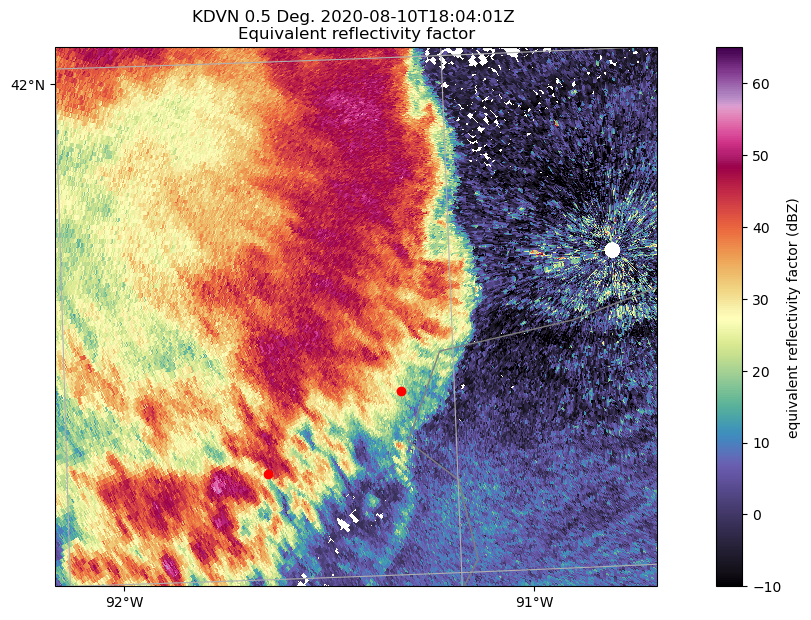

In [129]:
fig = plt.figure(figsize=(15, 7))
proj = ccrs.LambertConformal(central_longitude=-95, central_latitude=35,
                             standard_parallels=[35])

ax = fig.add_subplot(1, 1, 1, projection=proj)
myd = pyart.graph.RadarMapDisplay(radar)

myd.plot_ppi_map('reflectivity', cmap = pyart.graph.cmweather.cm_colorblind.ChaseSpectral, ax=ax, projection=proj, vmin=-10, vmax=65)
#ax = plt.gca()
ax.set_extent((-92.0, -90.5, 41.0, 42.0))
locslon = [-91.4867832, -91.1377283]
locslat = [41.2042301, 41.3557788]
#ax.plot(locslon, locslat, marker='o', color='red',markersize=8, transform=proj)
#ax.plot(locslon[1], locslat[1], , color='yellow', markersize=8, transform=mercator)
myd.plot_line_geo(locslon, locslat, 'ro')


In [ ]:
myd.plot_line_geo?

In [132]:
my_rhi = pyart.util.cross_section_ppi(radar, [180+60])

(0.0, 120.0)

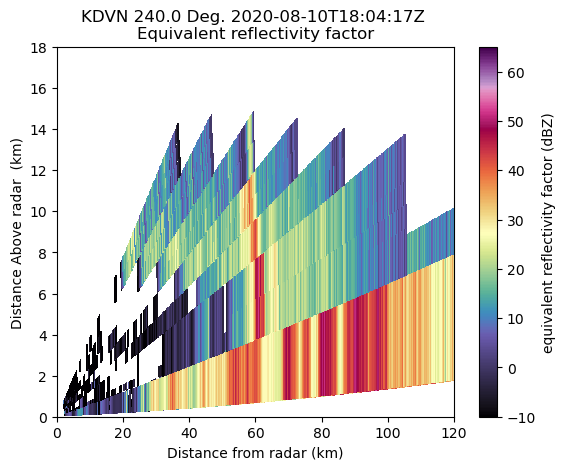

In [133]:
rdisp = pyart.graph.RadarDisplay(my_rhi)
rdisp.plot_rhi('reflectivity', 0, cmap=pyart.graph.cmweather.cm_colorblind.ChaseSpectral , vmin=-10, vmax=65)
plt.ylim(0,18)
plt.xlim(0, 120)